# Demo D: data loaded from an image with simulated periodic non-rigid motion

This demo uses a previously motion-corrected supine breast MRI image, which was saved in a .png format. It loads it and applies a sampling simulation (with 3 Nex, overriden directly in this script) and respiratory-like motion simulation. 


[Demo D bis] Loading config...
[Demo D bis] Initializing runtime...
[Demo D bis] Loading image data and building operators...
[DataLoader] k-space normalized (rms), scale=1.235129e-01


EspiritCalib:   0%|          | 0/100 [00:00<?, ?it/s]

Simulating realistic non-rigid motion fields...


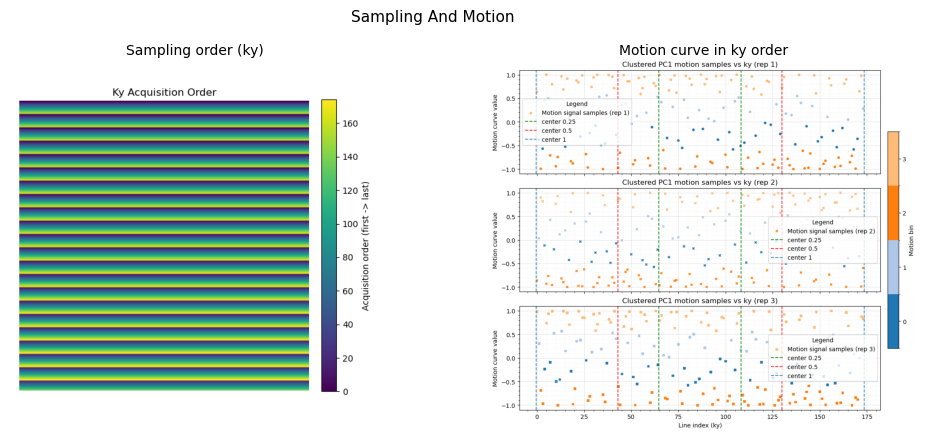

[Demo D bis] Starting reconstruction...


Resolution level 1/3:   0%|          | 0/10 [00:00<?, ?it/s]

Resolution level 2/3:   0%|          | 0/4 [00:00<?, ?it/s]

Resolution level 3/3:   0%|          | 0/4 [00:00<?, ?it/s]

Elapsed time: 82.85 s


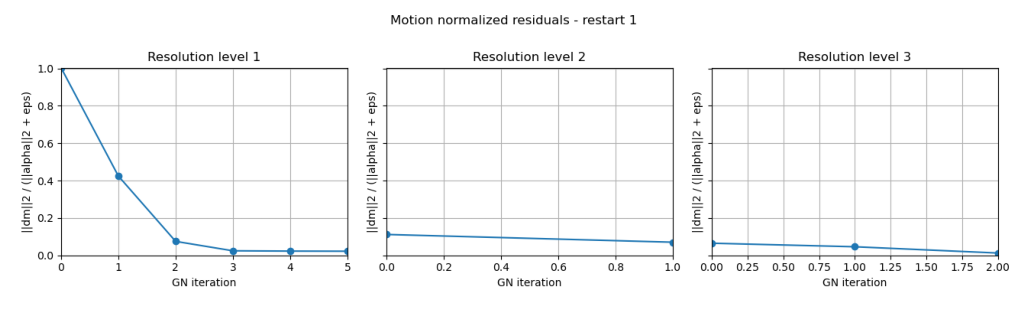

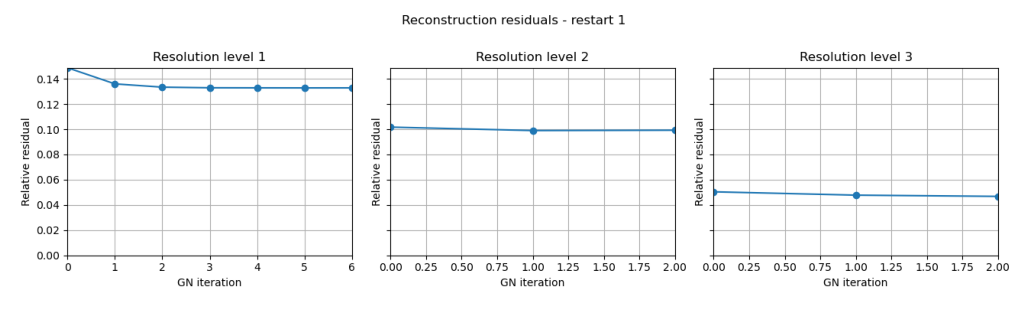

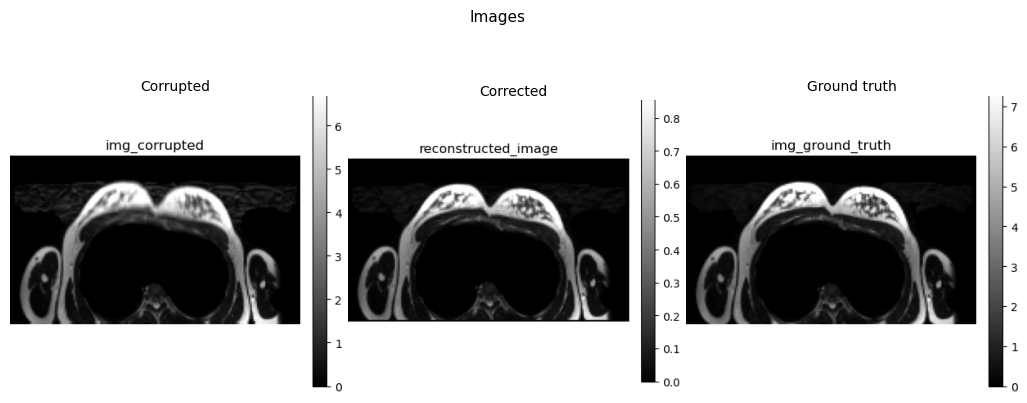

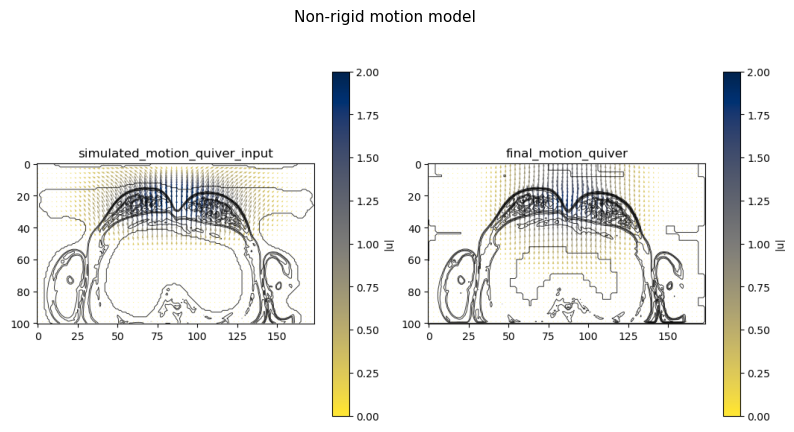

In [1]:
import time

from src.runtime.runtime_config import load_config
from src.preprocessing.DataLoader import DataLoader
from src.reconstruction.JointReconstructor import JointReconstructor
from src.utils.notebook_display import display_input_sampling_motion_panels, display_run_panels
from src.runtime.runtime_setup import initialize_runtime

jupyter_notebook_flag = True

def main():
    print("[Demo D bis] Loading config...")
    params = load_config(
        data_type="from_image",
        from_image_config="config/from_image.toml",
        sampling_config="config/sampling_simulation/interleaved.toml",
        motion_simulation_config="config/motion_simulation/nonrigid.toml",
        reconstruction_config="config/reconstruction/nonrigid_fast.toml",        
        overrides={
            "Nex": 3,
            "jupyter_notebook_flag": jupyter_notebook_flag,
        },
    )

    print("[Demo D bis] Initializing runtime...")
    sp_device, t_device = initialize_runtime(params)

    print("[Demo D bis] Loading image data and building operators...")
    data = DataLoader(
        params=params,
        t_device=t_device,
        sp_device=sp_device,
        filename="data/demo_motion-free_breast_image.png",
    )

    display_input_sampling_motion_panels(
        params,
    )

    print("[Demo D bis] Starting reconstruction...")
    recon = JointReconstructor(
        data.kspace,
        data.smaps,
        data.sampling_idx,
        motion_signal=data.motion_signal,
        params=params,
        kspace_scale=data.kspace_scale,
        motion_plot_context=data.motion_plot_context,
    )
    t0 = time.time()
    recon.run()
    print(f"Elapsed time: {time.time() - t0:.2f} s")

    display_run_panels(
        params,
        motion_type=params.motion_type,
    )


if __name__ == "__main__":
    main()
